<a href="https://colab.research.google.com/github/SwaroopMR/Raisin-Classification-using-Na-ve-Bayes-and-Exploratory-Data-Analysis/blob/main/raisin_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pandas openpyxl scikit-learn seaborn matplotlib numpy
from google.colab import files
print("Upload your Raisin_Dataset.xlsx file:")
uploaded = files.upload()

Upload your Raisin_Dataset.xlsx file:


Saving Raisin_Dataset.xlsx to Raisin_Dataset (1).xlsx


RAISIN CLASSIFICATION - DATA EXPLORATION & ANALYSIS

[1] DATASET OVERVIEW
------------------------------------------------------------
Dataset Shape: (900, 8)

First few rows:
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Kecimen  

[2] DATASET INFO
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #  

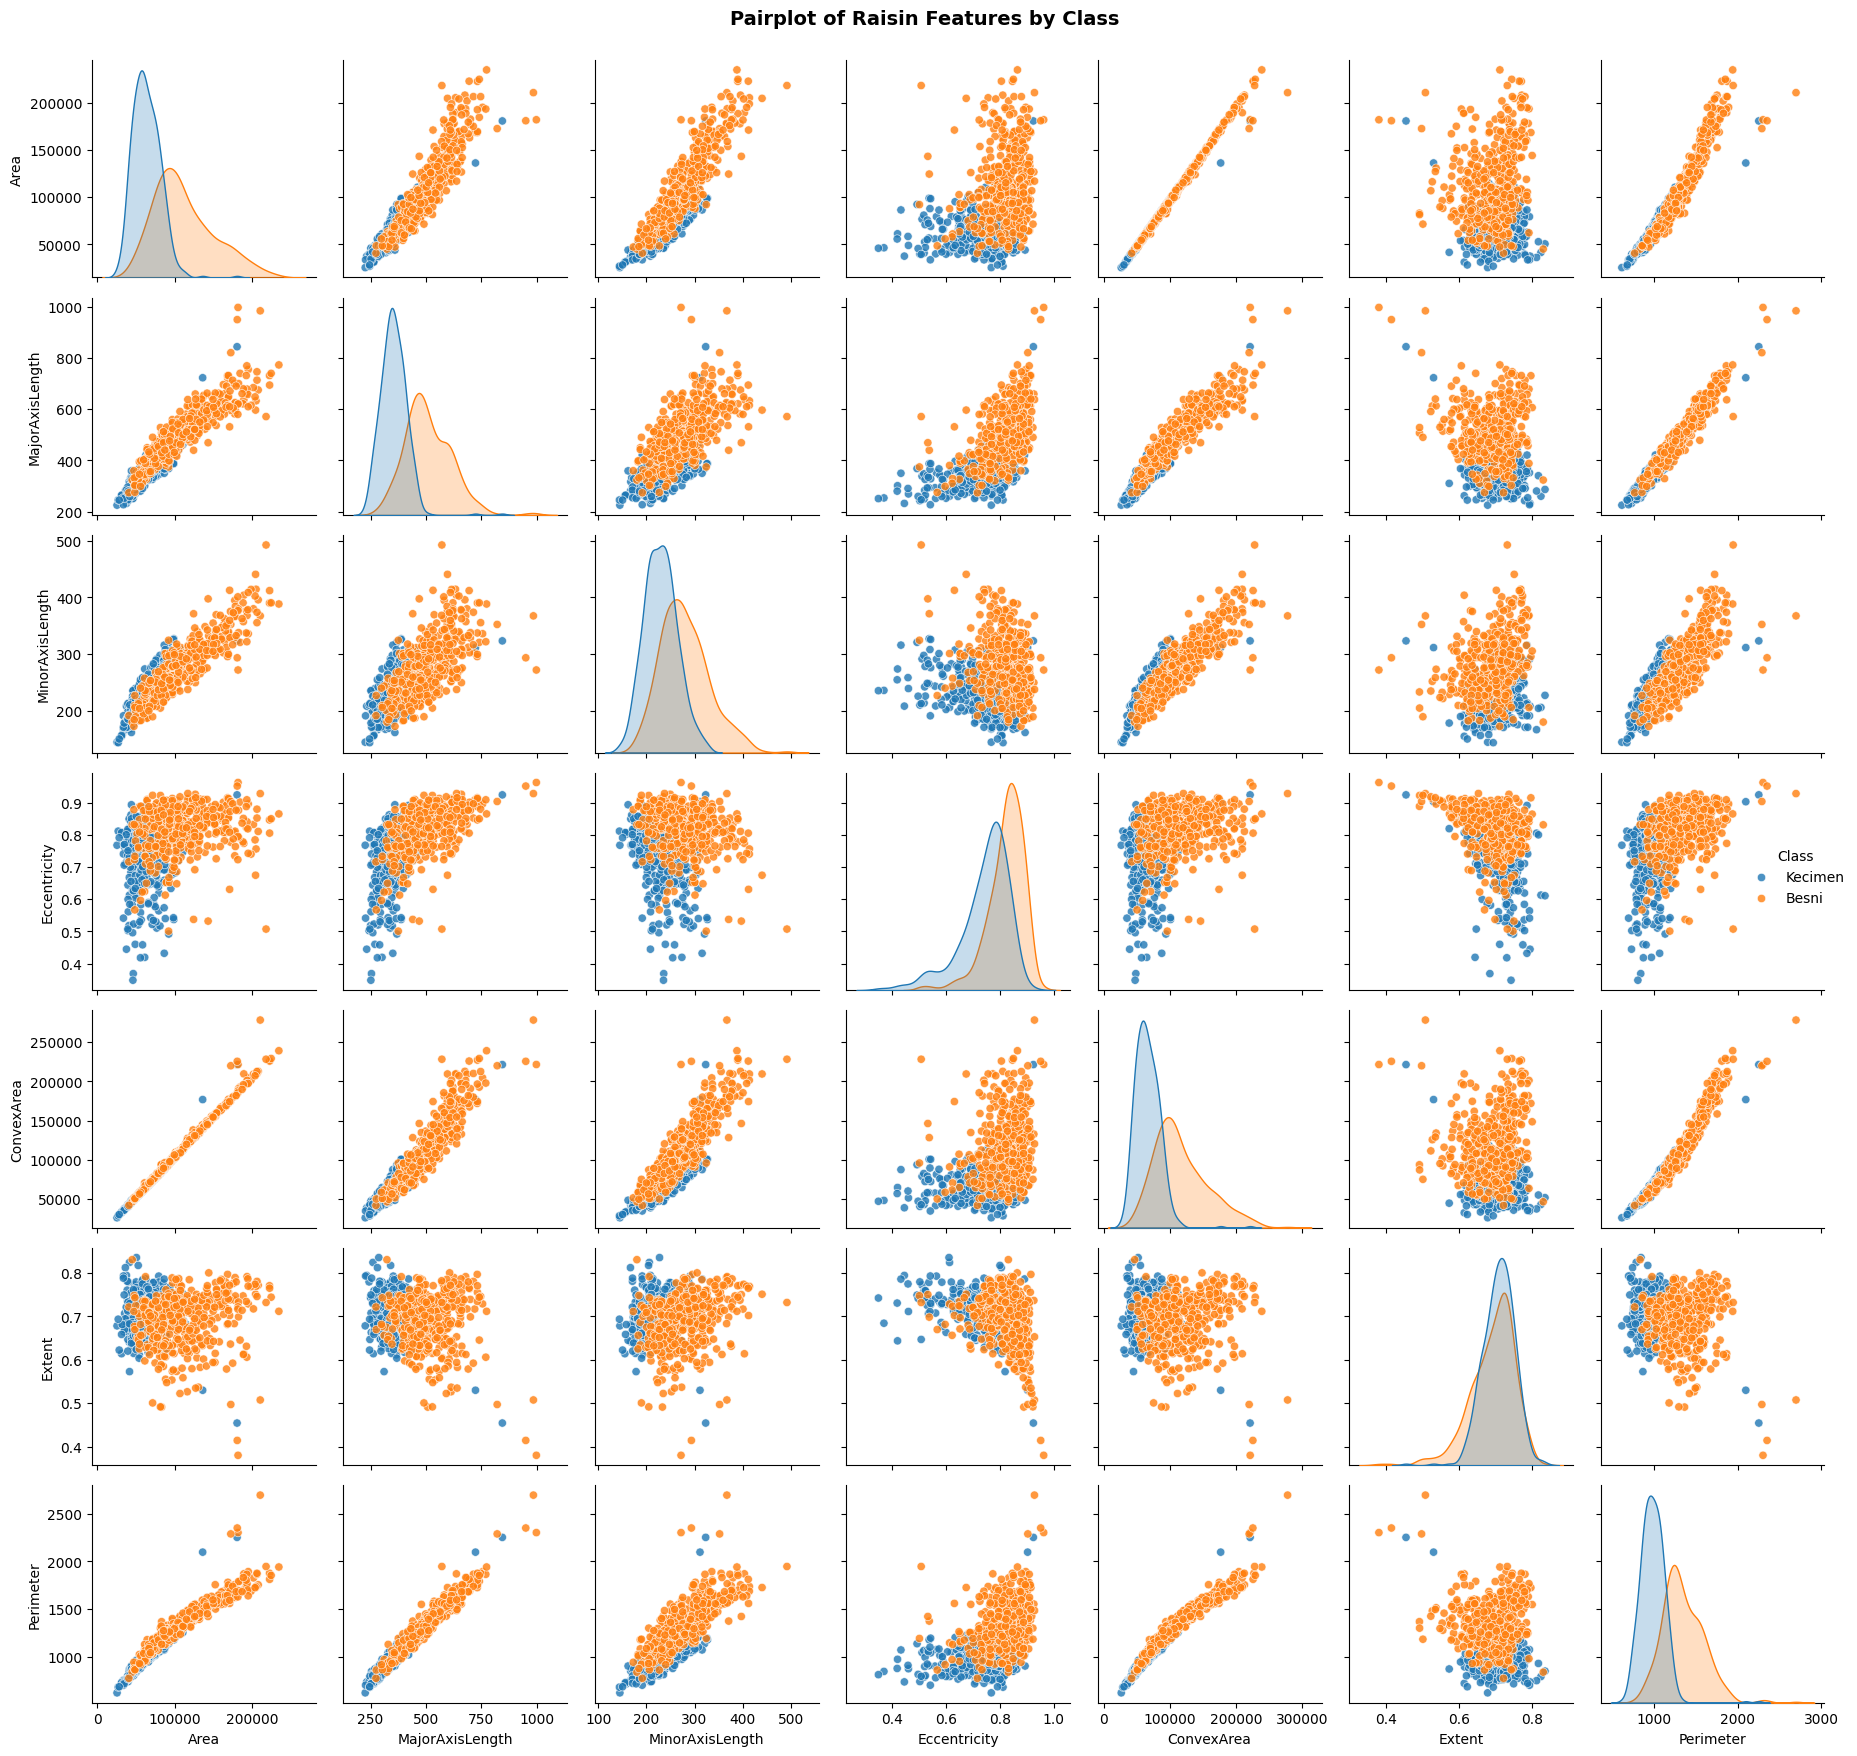

[6] Generating Correlation Matrix Heatmap...


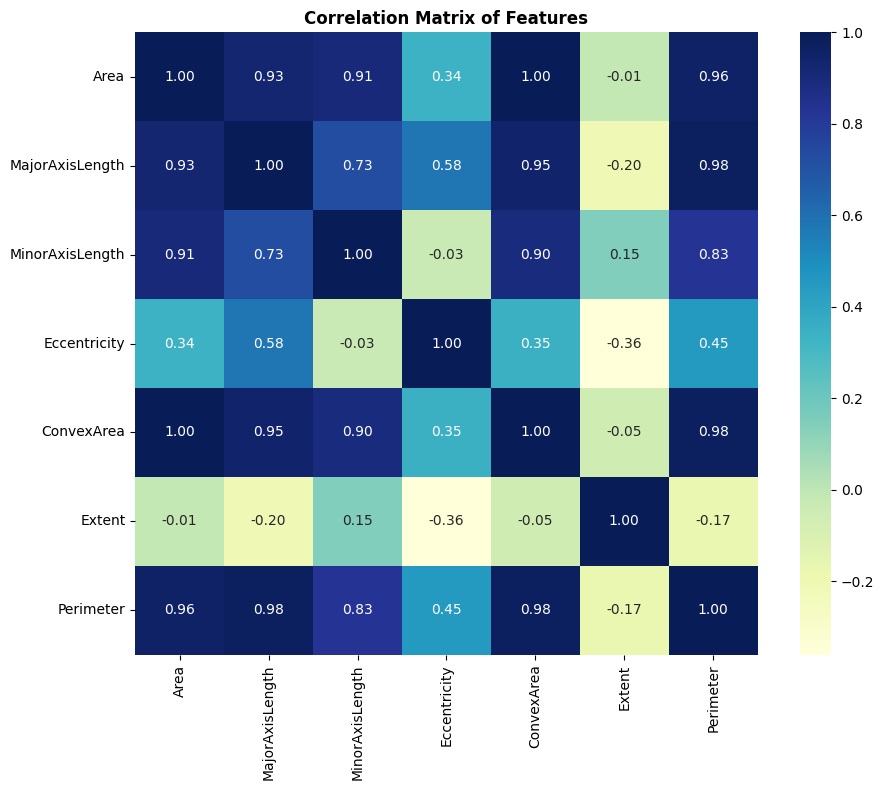


[7] Performing PCA Analysis...
Explained Variance Ratio: [0.99796189 0.00203684]
Cumulative Variance: 1.0000


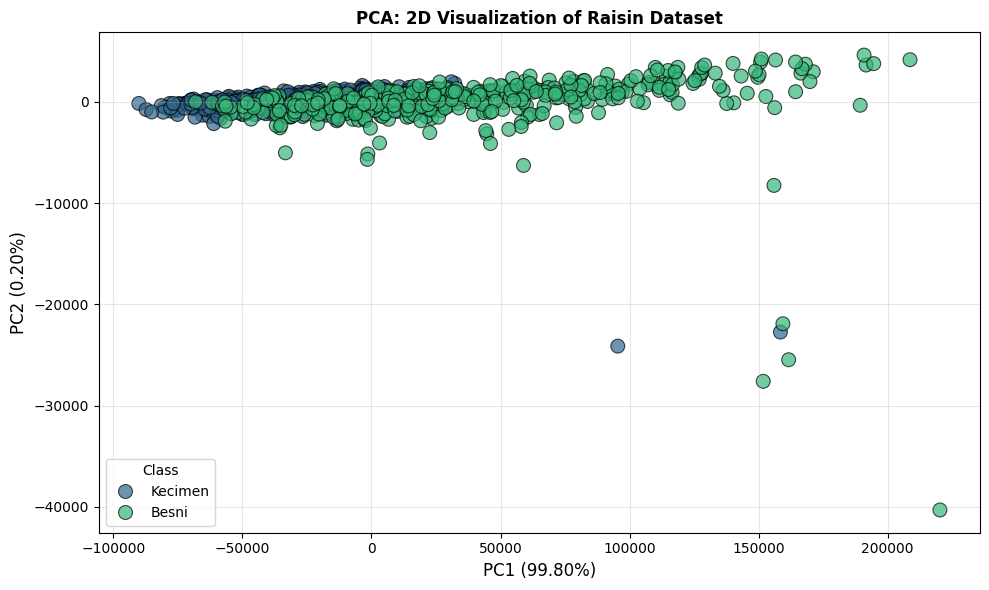


OUTLIER DETECTION & REMOVAL

[8] Using IQR Method to detect outliers...
  Area: 41 outliers detected (range: [-9172.38, 173548.62])
  MajorAxisLength: 7 outliers detected (range: [138.92, 682.53])
  MinorAxisLength: 7 outliers detected (range: [130.52, 362.29])
  Eccentricity: 40 outliers detected (range: [0.59, 0.99])
  ConvexArea: 12 outliers detected (range: [-2619.00, 168269.00])
  Extent: 16 outliers detected (range: [0.57, 0.83])
  Perimeter: 1 outliers detected (range: [514.42, 1706.47])

Original dataset size: 900
After outlier removal: 776
Rows removed: 124

[9] Generating Boxplot visualization...


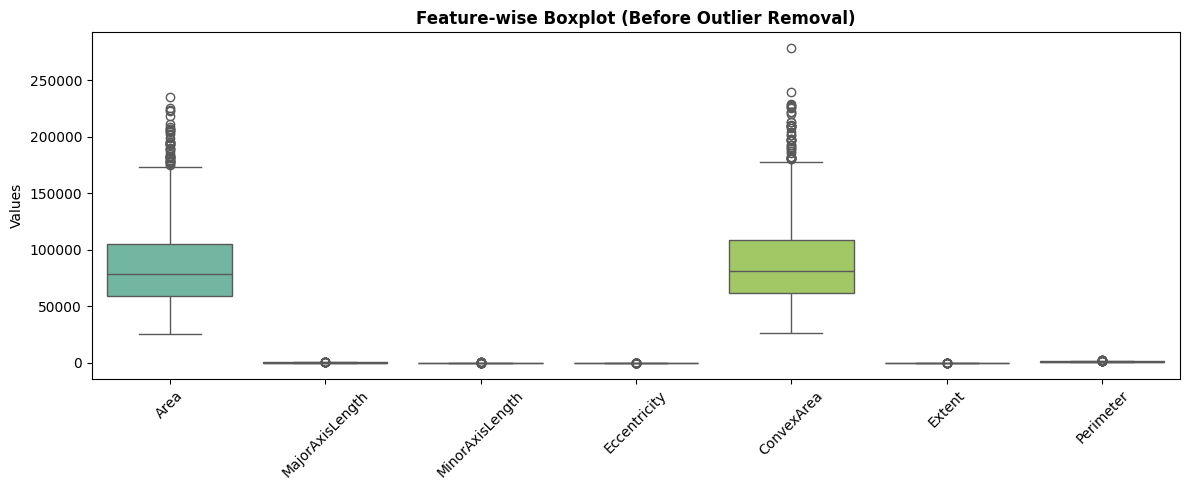


DATA PREPARATION FOR MODELING

[10] Features shape: (776, 7)
Target shape: (776,)

Feature columns: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']

Target classes: ['Besni', 'Kecimen']
Class distribution:
Class
Kecimen    408
Besni      368
Name: count, dtype: int64

[11] Train-Test Split:
  Training set shape: (620, 7)
  Test set shape: (156, 7)
  Training samples: 620
  Test samples: 156

GAUSSIAN NAIVE BAYES MODEL

[12] Training Gaussian Naive Bayes Model...
Model training completed!

MODEL EVALUATION

[13] Accuracy Scores:
  Train Accuracy: 81.77%
  Test Accuracy: 83.33%

[14] Classification Report (Test Set):
              precision    recall  f1-score   support

       Besni       0.85      0.78      0.82        74
     Kecimen       0.82      0.88      0.85        82

    accuracy                           0.83       156
   macro avg       0.84      0.83      0.83       156
weighted avg       0.83      0.83      0.83       15

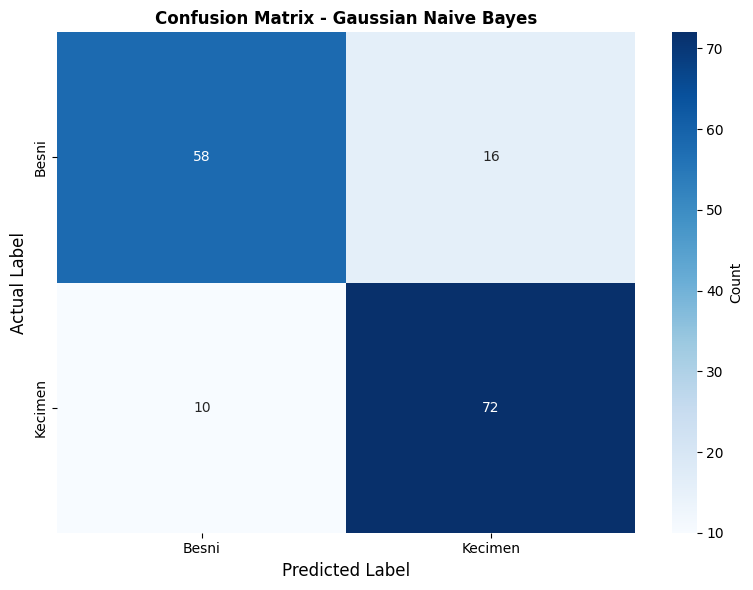


FINAL SUMMARY REPORT

Dataset Information:
  Original Size: 900 samples
  After Outlier Removal: 776 samples
  Number of Features: 7
  Number of Classes: 2

Model Performance:
  Train Accuracy: 81.77%
  Test Accuracy: 83.33%
  Overfitting Gap: -1.56%

PCA Analysis:
  Variance Explained (2 components): 100.00%

Analysis Complete!


In [6]:
"""
Raisin Classification using Naive Bayes and Exploratory Data Analysis
Google Colab Compatible Version
"""

# Setup for Colab (uncomment if running in Colab)
# !pip install pandas openpyxl scikit-learn seaborn matplotlib numpy
# from google.colab import files
# print("Upload your Raisin_Dataset.xlsx file:")
# uploaded = files.upload()

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# ============================================================
# 1. LOAD AND EXPLORE THE DATASET
# ============================================================
print("="*60)
print("RAISIN CLASSIFICATION - DATA EXPLORATION & ANALYSIS")
print("="*60)

# Load the dataset (Colab compatible path)
df = pd.read_excel("Raisin_Dataset.xlsx")

print("\n[1] DATASET OVERVIEW")
print("-" * 60)
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\n[2] DATASET INFO")
print("-" * 60)
print(df.info())

print("\n[3] STATISTICAL SUMMARY")
print("-" * 60)
print(df.describe())

print("\n[4] DATA QUALITY CHECK")
print("-" * 60)
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# ============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
# ============================================================
print("\n\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS & VISUALIZATION")
print("="*60)

# Pairplot
print("\n[5] Generating Pairplot (Feature Relationships)...")
sns.pairplot(df, hue='Class', plot_kws={'alpha': 0.8})
plt.suptitle('Pairplot of Raisin Features by Class', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

# Correlation Matrix Heatmap
print("[6] Generating Correlation Matrix Heatmap...")
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu', square=True, fmt='.2f')
plt.title("Correlation Matrix of Features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 3. DIMENSIONALITY REDUCTION - PCA
# ============================================================
print("\n[7] Performing PCA Analysis...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.iloc[:, :-1])

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative Variance: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Class'], s=100, palette='viridis', alpha=0.7, edgecolor='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
plt.title('PCA: 2D Visualization of Raisin Dataset', fontsize=12, fontweight='bold')
plt.legend(title='Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 4. OUTLIER DETECTION AND REMOVAL
# ============================================================
print("\n" + "="*60)
print("OUTLIER DETECTION & REMOVAL")
print("="*60)

features = df.columns[:-1]
df_filtered = df.copy()

print(f"\n[8] Using IQR Method to detect outliers...")
for f in features:
    Q1 = df_filtered[f].quantile(0.25)
    Q3 = df_filtered[f].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = len(df_filtered[(df_filtered[f] < lower) | (df_filtered[f] > upper)])
    if outliers_count > 0:
        print(f"  {f}: {outliers_count} outliers detected (range: [{lower:.2f}, {upper:.2f}])")

    df_filtered = df_filtered[(df_filtered[f] >= lower) & (df_filtered[f] <= upper)]

print(f"\nOriginal dataset size: {len(df)}")
print(f"After outlier removal: {len(df_filtered)}")
print(f"Rows removed: {len(df) - len(df_filtered)}")

# Boxplot for feature-wise outliers
print("\n[9] Generating Boxplot visualization...")
plt.figure(figsize=(12, 5))
sns.boxplot(data=df.iloc[:, :-1], palette='Set2')
plt.xticks(rotation=45)
plt.title("Feature-wise Boxplot (Before Outlier Removal)", fontsize=12, fontweight='bold')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

# ============================================================
# 5. DATA PREPARATION FOR MODELING
# ============================================================
print("\n" + "="*60)
print("DATA PREPARATION FOR MODELING")
print("="*60)

X = df_filtered.iloc[:, :-1]  # Features
y = df_filtered.iloc[:, -1]   # Target (Class)

print(f"\n[10] Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"\nTarget classes: {sorted(y.unique())}")
print(f"Class distribution:\n{y.value_counts()}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\n[11] Train-Test Split:")
print(f"  Training set shape: {X_train.shape}")
print(f"  Test set shape: {X_test.shape}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")

# ============================================================
# 6. BUILD AND TRAIN GAUSSIAN NAIVE BAYES MODEL
# ============================================================
print("\n" + "="*60)
print("GAUSSIAN NAIVE BAYES MODEL")
print("="*60)

print("\n[12] Training Gaussian Naive Bayes Model...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = nb_model.predict(X_train)
y_pred_test = nb_model.predict(X_test)

print("Model training completed!")

# ============================================================
# 7. MODEL EVALUATION
# ============================================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Accuracy Scores
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n[13] Accuracy Scores:")
print(f"  Train Accuracy: {train_acc * 100:.2f}%")
print(f"  Test Accuracy: {test_acc * 100:.2f}%")

# Classification Report
print(f"\n[14] Classification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
print(f"\n[15] Confusion Matrix:")
labels = sorted(df['Class'].unique())
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

# Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Confusion Matrix - Gaussian Naive Bayes", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 8. SUMMARY REPORT
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY REPORT")
print("="*60)
print(f"\nDataset Information:")
print(f"  Original Size: {len(df)} samples")
print(f"  After Outlier Removal: {len(df_filtered)} samples")
print(f"  Number of Features: {X.shape[1]}")
print(f"  Number of Classes: {len(np.unique(y))}")

print(f"\nModel Performance:")
print(f"  Train Accuracy: {train_acc * 100:.2f}%")
print(f"  Test Accuracy: {test_acc * 100:.2f}%")
print(f"  Overfitting Gap: {(train_acc - test_acc) * 100:.2f}%")

print(f"\nPCA Analysis:")
print(f"  Variance Explained (2 components): {sum(pca.explained_variance_ratio_):.2%}")

print("\n" + "="*60)
print("Analysis Complete!")
print("="*60)